# Tratamento de dados de atletas olímpicos

**Conjunto de dados:** *120 years of Olympic history: athletes and results*

Este trabalho executa, documenta e valida todas as etapas solicitadas na
atividade: ingestão, inspeção, remoção de duplicatas, tratamento de idade,
altura e peso, validação final e exportação. O dataframe principal recebe o
nome `atletas`, conforme exigido.

## 1. Configuração e caminhos

O bloco funciona tanto como arquivo Python quanto como Notebook executado a
partir da raiz do projeto. A semente visual e o estilo são fixos para tornar
o resultado reproduzível.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()

try:
    get_ipython()
    EXECUTANDO_NOTEBOOK = True
except NameError:
    EXECUTANDO_NOTEBOOK = False

DATA_DIR = ROOT / "data"
INPUT_CSV = DATA_DIR / "athlete_events.csv"
OUTPUT_CSV = DATA_DIR / "athlete_events_clean.csv"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")

if not INPUT_CSV.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {INPUT_CSV}. "
        "Baixe e extraia o conjunto de dados do Kaggle na pasta data/."
    )

## 2. Ingestão e conhecimento dos dados

O arquivo `athlete_events.csv` é carregado no dataframe `atletas`. Em seguida,
são exibidos uma amostra, as dimensões, os tipos e o resumo estatístico das
variáveis de interesse (`Age`, `Height` e `Weight`).

In [2]:
atletas = pd.read_csv(INPUT_CSV)

colunas_esperadas = {
    "ID", "Name", "Sex", "Age", "Height", "Weight", "Team", "NOC",
    "Games", "Year", "Season", "City", "Sport", "Event", "Medal",
}
assert set(atletas.columns) == colunas_esperadas, "O esquema da base é inesperado."
assert not atletas.empty, "O dataframe atletas não pode estar vazio."

print("Primeiras cinco linhas do dataframe atletas:")
print(atletas.head().to_string(index=False))
print(f"\nDimensões iniciais: {atletas.shape[0]:,} linhas x {atletas.shape[1]} colunas")
print("\nTipos e preenchimento das colunas:")
atletas.info()
print("\nResumo das variáveis de interesse:")
print(atletas[["Age", "Height", "Weight"]].describe().round(2).to_string())

Primeiras cinco linhas do dataframe atletas:
 ID                     Name Sex  Age  Height  Weight           Team NOC       Games  Year Season      City         Sport                            Event Medal
  1                A Dijiang   M 24.0   180.0    80.0          China CHN 1992 Summer  1992 Summer Barcelona    Basketball      Basketball Men's Basketball   NaN
  2                 A Lamusi   M 23.0   170.0    60.0          China CHN 2012 Summer  2012 Summer    London          Judo     Judo Men's Extra-Lightweight   NaN
  3      Gunnar Nielsen Aaby   M 24.0     NaN     NaN        Denmark DEN 1920 Summer  1920 Summer Antwerpen      Football          Football Men's Football   NaN
  4     Edgar Lindenau Aabye   M 34.0     NaN     NaN Denmark/Sweden DEN 1900 Summer  1900 Summer     Paris    Tug-Of-War      Tug-Of-War Men's Tug-Of-War  Gold
  5 Christine Jacoba Aaftink   F 21.0   185.0    82.0    Netherlands NED 1988 Winter  1988 Winter   Calgary Speed Skating Speed Skating Women's 500 me

## 3. Diagnóstico de qualidade

Uma duplicata é definida como uma linha idêntica em todas as 15 colunas.
Repetições de um mesmo `ID` em provas diferentes não são erros: um atleta
pode participar de vários eventos e edições. Também medimos os dados ausentes
antes de qualquer correção.

Linhas exatamente duplicadas: 1,385

Valores ausentes antes do tratamento:
Age        9474
Height    60171
Weight    62875


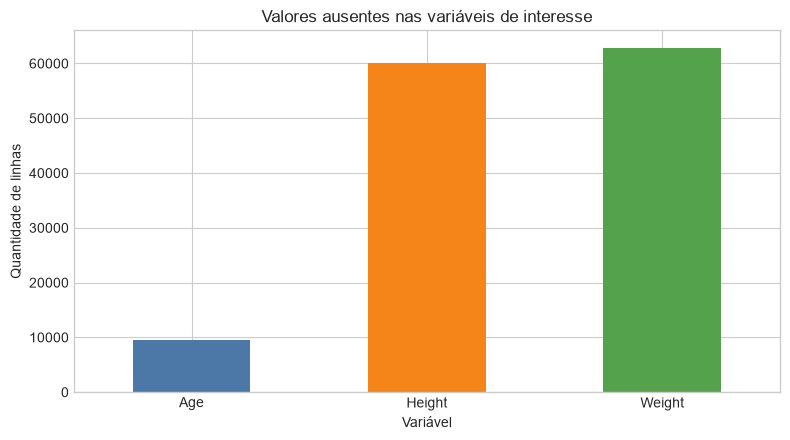

In [3]:
linhas_iniciais = len(atletas)
duplicatas_antes = int(atletas.duplicated().sum())
ausentes_antes = atletas[["Age", "Height", "Weight"]].isna().sum()

print(f"Linhas exatamente duplicadas: {duplicatas_antes:,}")
print("\nValores ausentes antes do tratamento:")
print(ausentes_antes.to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
ausentes_antes.plot.bar(ax=ax, color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_title("Valores ausentes nas variáveis de interesse")
ax.set_xlabel("Variável")
ax.set_ylabel("Quantidade de linhas")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(DATA_DIR / "missing_values_before.png", dpi=150, bbox_inches="tight")
if EXECUTANDO_NOTEBOOK:
    plt.show()
else:
    plt.close(fig)

## 4. Remoção e verificação de duplicatas

As linhas duplicadas são removidas e o resultado é explicitamente verificado,
como determina a rubrica.

In [4]:
atletas = atletas.drop_duplicates().reset_index(drop=True)
duplicatas_depois = int(atletas.duplicated().sum())
removidas_duplicadas = linhas_iniciais - len(atletas)

assert duplicatas_antes > 0, "A etapa deveria detectar duplicatas na base original."
assert removidas_duplicadas == duplicatas_antes, "Nem todas as duplicatas foram removidas."
assert duplicatas_depois == 0, "Ainda existem linhas duplicadas."

print(f"Duplicatas removidas: {removidas_duplicadas:,}")
print(f"Duplicatas após a limpeza: {duplicatas_depois}")
print(f"Linhas restantes: {len(atletas):,}")

Duplicatas removidas: 1,385
Duplicatas após a limpeza: 0
Linhas restantes: 269,731


## 5. Tratamento e verificação da idade

A atividade determina que idades ausentes sejam substituídas pela média das
idades de todos os registros válidos. A média é calculada depois da remoção
das duplicatas, evitando que registros repetidos influenciem o valor.

In [5]:
idades_ausentes_antes = int(atletas["Age"].isna().sum())
media_idade = float(atletas["Age"].mean())
atletas["Age"] = atletas["Age"].fillna(media_idade)
idades_ausentes_depois = int(atletas["Age"].isna().sum())

assert idades_ausentes_antes > 0, "A etapa deveria detectar idades ausentes."
assert pd.notna(media_idade), "Não foi possível calcular a média de idade."
assert idades_ausentes_depois == 0, "Ainda existem idades ausentes."

print(f"Idades ausentes identificadas: {idades_ausentes_antes:,}")
print(f"Média usada no preenchimento: {media_idade:.4f} anos")
print(f"Idades ausentes após o preenchimento: {idades_ausentes_depois}")

Idades ausentes identificadas: 9,315
Média usada no preenchimento: 25.4548 anos
Idades ausentes após o preenchimento: 0


## 6. Tratamento e verificação da altura

Seguindo o critério de excelência da rubrica, linhas sem altura são removidas.
Não se imputa altura porque ela é central para as análises propostas e uma
estimativa acrescentaria valores artificiais a uma parcela grande da base.

In [6]:
alturas_ausentes_antes = int(atletas["Height"].isna().sum())
linhas_antes_altura = len(atletas)
atletas = atletas.dropna(subset=["Height"]).reset_index(drop=True)
alturas_ausentes_depois = int(atletas["Height"].isna().sum())
removidas_sem_altura = linhas_antes_altura - len(atletas)

assert alturas_ausentes_antes > 0, "A etapa deveria detectar alturas ausentes."
assert removidas_sem_altura == alturas_ausentes_antes, "A remoção de alturas está inconsistente."
assert alturas_ausentes_depois == 0, "Ainda existem alturas ausentes."

print(f"Alturas ausentes identificadas: {alturas_ausentes_antes:,}")
print(f"Linhas removidas por falta de altura: {removidas_sem_altura:,}")
print(f"Alturas ausentes após a remoção: {alturas_ausentes_depois}")

Alturas ausentes identificadas: 58,814
Linhas removidas por falta de altura: 58,814
Alturas ausentes após a remoção: 0


## 7. Tratamento e verificação do peso

Para peso, optou-se por imputar a mediana do grupo `Sex` + `Sport`. Essa
estratégia preserva registros que já possuem idade e altura, respeita diferenças
corporais entre modalidades e sexos e é menos sensível a valores extremos que
a média. Caso um grupo não tenha peso observado, usa-se a mediana do sexo e,
por último, a mediana global, garantindo cobertura completa.

In [7]:
pesos_ausentes_antes = int(atletas["Weight"].isna().sum())
mediana_peso_grupo = atletas.groupby(["Sex", "Sport"])["Weight"].transform("median")
mediana_peso_sexo = atletas.groupby("Sex")["Weight"].transform("median")
mediana_peso_global = float(atletas["Weight"].median())

atletas["Weight"] = (
    atletas["Weight"]
    .fillna(mediana_peso_grupo)
    .fillna(mediana_peso_sexo)
    .fillna(mediana_peso_global)
)
pesos_ausentes_depois = int(atletas["Weight"].isna().sum())

assert pesos_ausentes_antes > 0, "A etapa deveria detectar pesos ausentes."
assert pd.notna(mediana_peso_global), "Não foi possível calcular a mediana de peso."
assert pesos_ausentes_depois == 0, "Ainda existem pesos ausentes."

print(f"Pesos ausentes identificados: {pesos_ausentes_antes:,}")
print(f"Mediana global de contingência: {mediana_peso_global:.2f} kg")
print(f"Pesos ausentes após a imputação: {pesos_ausentes_depois}")

Pesos ausentes identificados: 4,077
Mediana global de contingência: 70.00 kg
Pesos ausentes após a imputação: 0


## 8. Validação final

As verificações abaixo garantem que as três variáveis de interesse estejam
completas, que não haja duplicatas e que idade, altura e peso sejam positivos.
Valores extremos plausíveis não são removidos automaticamente: modalidades
olímpicas possuem perfis corporais muito diferentes.

Valores ausentes em `Medal` são mantidos, pois significam que o atleta não
ganhou medalha, e não uma falha de coleta relevante para esta tarefa.

In [8]:
variaveis_interesse = ["Age", "Height", "Weight"]
ausentes_finais = atletas[variaveis_interesse].isna().sum()
duplicatas_finais = int(atletas.duplicated().sum())
valores_nao_positivos = (atletas[variaveis_interesse] <= 0).sum()

assert int(ausentes_finais.sum()) == 0, "Ainda existem ausências nas variáveis de interesse."
assert duplicatas_finais == 0, "Ainda existem duplicatas no resultado final."
assert int(valores_nao_positivos.sum()) == 0, "Foram encontrados valores não positivos."
assert len(atletas) == linhas_iniciais - duplicatas_antes - alturas_ausentes_antes

print("Valores ausentes ao final:")
print(ausentes_finais.to_string())
print(f"\nDuplicatas ao final: {duplicatas_finais}")
print("\nValores não positivos ao final:")
print(valores_nao_positivos.to_string())
print("\nResumo estatístico final:")
print(atletas[variaveis_interesse].describe().round(2).to_string())

Valores ausentes ao final:
Age       0
Height    0
Weight    0

Duplicatas ao final: 0

Valores não positivos ao final:
Age       0
Height    0
Weight    0

Resumo estatístico final:
             Age     Height     Weight
count  210917.00  210917.00  210917.00
mean       25.09     175.34      70.71
std         5.52      10.52      14.25
min        11.00     127.00      25.00
25%        21.00     168.00      61.00
50%        24.00     175.00      70.00
75%        28.00     183.00      79.00
max        71.00     226.00     214.00


## 9. Exportação e balanço do tratamento

A base validada é salva em CSV. A leitura do arquivo exportado confirma que
o número de linhas, as colunas e a completude das variáveis de interesse foram
preservados no disco.

In [9]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
atletas.to_csv(OUTPUT_CSV, index=False)

atletas_exportados = pd.read_csv(OUTPUT_CSV)
assert atletas_exportados.shape == atletas.shape, "O CSV exportado possui dimensões incorretas."
assert list(atletas_exportados.columns) == list(atletas.columns), "As colunas exportadas mudaram."
assert not atletas_exportados[variaveis_interesse].isna().any().any()

resumo_tratamento = pd.Series(
    {
        "Linhas na entrada": linhas_iniciais,
        "Duplicatas removidas": removidas_duplicadas,
        "Idades preenchidas": idades_ausentes_antes,
        "Linhas sem altura removidas": removidas_sem_altura,
        "Pesos preenchidos": pesos_ausentes_antes,
        "Linhas na saída": len(atletas),
    },
    name="Quantidade",
)

print("Balanço final do tratamento:")
print(resumo_tratamento.to_string())
print(f"\nArquivo validado e salvo em: {OUTPUT_CSV}")

Balanço final do tratamento:
Linhas na entrada              271116
Duplicatas removidas             1385
Idades preenchidas               9315
Linhas sem altura removidas     58814
Pesos preenchidos                4077
Linhas na saída                210917

Arquivo validado e salvo em: C:\Code\SENAI CIMATEC\Big Data Treatment\data\athlete_events_clean.csv
